<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


### Imports

In [1]:
# Standard library
import urllib.request

# Third-party
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bs4 as bs
from scipy.special import softmax

# TensorFlow / Keras
from tensorflow import keras
from tensorflow.keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, SimpleRNN, TimeDistributed, CategoryEncoding, Input

### Datos
Utilizaremos como dataset el libro La vuelta al mundo en 80 días de Julio Verne.

In [2]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'html.parser')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [3]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \r\n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\r\n pesar de que parecía haber tomado el partido de no hacer nada que \r\npudiese llamar la atención, era uno de los miembros más notables y \r\nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \r\nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \r\nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \r\nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \r\nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \r\nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\r\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\r\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \r\nninguno de los despachos mercantiles de 

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [4]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [5]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [6]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

68

In [7]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [8]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [9]:
tokenized_text[:1000]

[14,
 49,
 3,
 14,
 49,
 28,
 14,
 0,
 46,
 17,
 14,
 43,
 35,
 23,
 10,
 19,
 14,
 28,
 0,
 14,
 1,
 0,
 53,
 0,
 14,
 3,
 54,
 65,
 49,
 44,
 17,
 14,
 23,
 14,
 34,
 49,
 14,
 53,
 0,
 40,
 47,
 28,
 28,
 49,
 36,
 44,
 17,
 60,
 19,
 14,
 22,
 5,
 44,
 28,
 47,
 3,
 7,
 42,
 17,
 3,
 14,
 7,
 0,
 44,
 34,
 49,
 3,
 53,
 14,
 29,
 4,
 26,
 34,
 17,
 3,
 34,
 49,
 14,
 65,
 5,
 44,
 47,
 37,
 14,
 53,
 51,
 49,
 44,
 47,
 34,
 0,
 3,
 14,
 49,
 3,
 14,
 43,
 35,
 43,
 50,
 26,
 14,
 49,
 53,
 42,
 0,
 22,
 0,
 14,
 51,
 0,
 22,
 47,
 42,
 0,
 34,
 0,
 14,
 55,
 17,
 44,
 14,
 55,
 51,
 47,
 28,
 49,
 0,
 53,
 14,
 57,
 17,
 7,
 7,
 19,
 14,
 45,
 5,
 47,
 49,
 3,
 14,
 0,
 29,
 4,
 14,
 55,
 49,
 53,
 0,
 44,
 14,
 34,
 49,
 14,
 45,
 5,
 49,
 14,
 55,
 0,
 44,
 49,
 1,
 11,
 0,
 14,
 51,
 0,
 22,
 49,
 44,
 14,
 42,
 17,
 65,
 0,
 34,
 17,
 14,
 49,
 28,
 14,
 55,
 0,
 44,
 42,
 47,
 34,
 17,
 14,
 34,
 49,
 14,
 3,
 17,
 14,
 51,
 0,
 1,
 49,
 44,
 14,
 3,
 0,
 34,
 0,
 14,
 45,
 5

### Organizando y estructurando el dataset

In [10]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [11]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [12]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [13]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [14]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [15]:
X.shape

(359671, 100)

In [16]:
X[0,:10]

array([14, 49,  3, 14, 49, 28, 14,  0, 46, 17])

In [17]:
y[0,:10]

array([49,  3, 14, 49, 28, 14,  0, 46, 17, 14])

In [18]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

**Nota 2**: Se utilizó el PerplexityCallback definido en el ejercicio de la clase 4.

Se definen metodos genéricos para crear y entrenar el modelo segun el tipo (SimpleRNN, LSTM o GRU)

In [19]:
class PerplexityCallback(keras.callbacks.Callback):
    """Callback para calcular y registrar la perplejidad durante el entrenamiento."""

    def __init__(self):
        super().__init__()
        self.history_ppl = []

    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get('loss')
        if train_loss is not None:
            train_perplexity = np.exp(train_loss)
            print(f'\nTraining Perplexity: {train_perplexity:.4f}')
            logs['perplexity'] = train_perplexity
            self.history_ppl.append(train_perplexity)


def create_model(cell_type='SimpleRNN', units=200):
    """
    Crea un modelo de lenguaje con la celda recurrente especificada.

    Args:
        cell_type: 'SimpleRNN', 'LSTM' o 'GRU'
        units: número de unidades en la capa recurrente
    """
    model = Sequential()
    model.add(Input(shape=(None, 1)))
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot")))

    if cell_type == 'SimpleRNN':
        model.add(SimpleRNN(units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
    elif cell_type == 'LSTM':
        model.add(LSTM(units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
    elif cell_type == 'GRU':
        model.add(GRU(units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
    else:
        raise ValueError(f"cell_type debe ser 'SimpleRNN', 'LSTM' o 'GRU'. Se recibió: {cell_type}")

    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model


def train_model(model, name, epochs=20, batch_size=4096):
    """
    Entrena el modelo y guarda los resultados.

    Returns:
        history_ppl: lista con la perplejidad por época
    """
    callback = PerplexityCallback()
    model.fit(X, y, epochs=epochs, callbacks=[callback], batch_size=batch_size)
    model.save(f'{name}.keras')
    return callback.history_ppl

### Generación de secuencias

In [20]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

###  Beam search y muestreo aleatorio

In [21]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [22]:
# función que selecciona candidatos para el beam search
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    # colectar todas las probabilidades para la siguiente búsqueda
    pred_large = []

    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1E-10) + history_probs[idx])

    pred_large = np.array(pred_large)

    # criterio de selección
    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large / temp))
    else:
        raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

    # traducir a índices de token en el vocabulario
    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size],
         np.array([idx_select % vocab_size]).T),
        axis=1
    )

    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, mode='det'):
    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode
    )

    # beam search loop
    for i in range(num_words - 1):
        preds = []

        for hist in history_tokens:
            input_update = np.array([hist[i + 1:]]).copy()
            y_hat = model.predict(input_update, verbose=0)[0, -1, :]
            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input) + num_words):]

In [23]:
def show_generations(model, input_text="habia una vez", n_chars=30):
    """
    Muestra las generaciones con diferentes estrategias.
    """
    print(f"Input: '{input_text}'")
    print("-" * 50)
    print("Greedy search:")
    print(generate_seq(model, input_text, max_context_size, n_chars))
    print()
    print("Beam search (determinístico):")
    salidas_det = beam_search(model, num_beams=10, num_words=20, input=input_text, mode='det')
    print(decode(salidas_det[0]))
    print()
    print("Beam search (estocástico):")
    salidas_sto = beam_search(model, num_beams=10, num_words=20, input=input_text, mode='sto')
    print(decode(salidas_sto[0]))

## Entrenamiento

### SimpleRNN

In [24]:
# Crear y entrenar el modelo SimpleRNN
model = create_model('SimpleRNN', units=200)
model.summary()

history_ppl = train_model(model, 'simpleRNN')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 68)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        53,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 68)       │        13,668 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,468 (263.55 KB)

 Trainable params: 67,468 (263.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 3.2114
Training Perplexity: 19.7240
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - loss: 2.9818 - perplexity: 19.7240
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 2.6125
Training Perplexity: 12.5730
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 2.5316 - perplexity: 12.5730
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 2.3651
Training Perplexity: 10.3542
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 2.3374 - perplexity: 10.3542
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 2.2777
Training Perplexity: 9.6337
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 2.2653 - perplexity: 9.6337
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 2.2309
Training Perplexity: 9.2285
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 2.2223 - perplexity: 9.2285
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 2.1944
Training Perplexity: 8.9060
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 127

In [25]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('simpleRNN.keras')

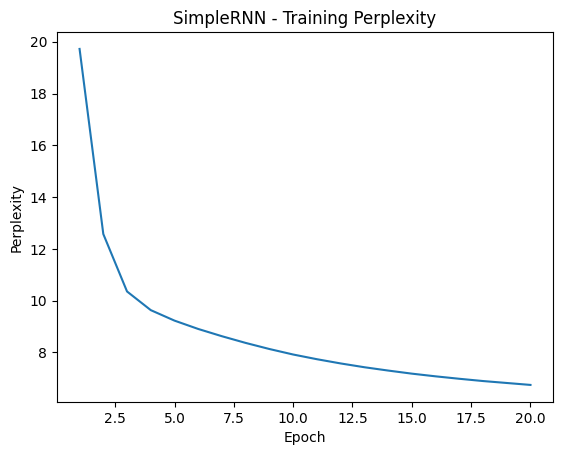

In [26]:
# Visualización de perplejidad
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count, y=history_ppl)
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('SimpleRNN - Training Perplexity')
plt.show()

### LSTM

In [27]:
# Crear y entrenar el modelo LSTM
model_lstm = create_model('LSTM', units=200)
model_lstm.summary()

history_ppl_lstm = train_model(model_lstm, 'LSTM')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 68)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       215,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 68)       │        13,668 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,868 (894.02 KB)

 Trainable params: 228,868 (894.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - loss: 3.3287
Training Perplexity: 22.8262
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 506ms/step - loss: 3.1279 - perplexity: 22.8262
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - loss: 2.9696
Training Perplexity: 18.7376
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 495ms/step - loss: 2.9305 - perplexity: 18.7376
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - loss: 2.7856
Training Perplexity: 15.4674
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 504ms/step - loss: 2.7387 - perplexity: 15.4674
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - loss: 2.6195
Training Perplexity: 13.3232
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 497ms/step - loss: 2.5895 - perplexity: 13.3232
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - loss: 2.5183
Training Perplexity: 12.1559
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 502ms/step - loss: 2.4978 - perplexity: 12.1559
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - loss: 2.4489
Training Perplexity: 11.4170
88/88 ━━━━━━━━━━━━━━━━━━━━ 44

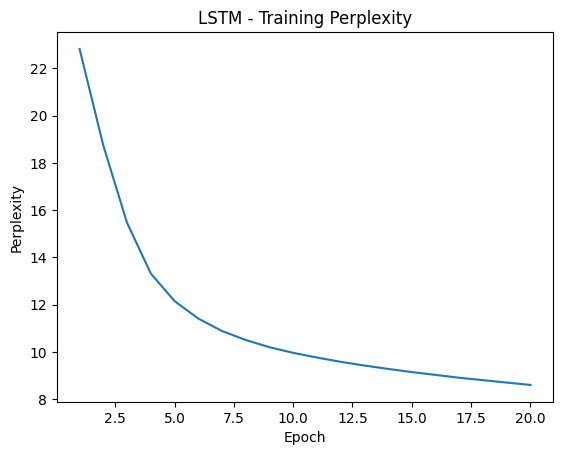

In [28]:
# Cargar modelo y visualizar perplejidad LSTM
model_lstm = keras.models.load_model('LSTM.keras')

epoch_count_lstm = range(1, len(history_ppl_lstm) + 1)
sns.lineplot(x=epoch_count_lstm, y=history_ppl_lstm)
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('LSTM - Training Perplexity')
plt.show()

### GRU

In [29]:
# Crear y entrenar el modelo GRU
model_gru = create_model('GRU', units=200)
model_gru.summary()

history_ppl_gru = train_model(model_gru, 'GRU')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 68)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       162,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 68)       │        13,668 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,668 (686.20 KB)

 Trainable params: 175,668 (686.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - loss: 3.3902
Training Perplexity: 22.0999
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 437ms/step - loss: 3.0956 - perplexity: 22.0999
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - loss: 2.6990
Training Perplexity: 13.6261
88/88 ━━━━━━━━━━━━━━━━━━━━ 41s 433ms/step - loss: 2.6120 - perplexity: 13.6261
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - loss: 2.4412
Training Perplexity: 11.1567
88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 435ms/step - loss: 2.4120 - perplexity: 11.1567
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - loss: 2.3444
Training Perplexity: 10.2821
88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 434ms/step - loss: 2.3304 - perplexity: 10.2821
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - loss: 2.2910
Training Perplexity: 9.7753
88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 432ms/step - loss: 2.2799 - perplexity: 9.7753
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - loss: 2.2445
Training Perplexity: 9.3389
88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 4

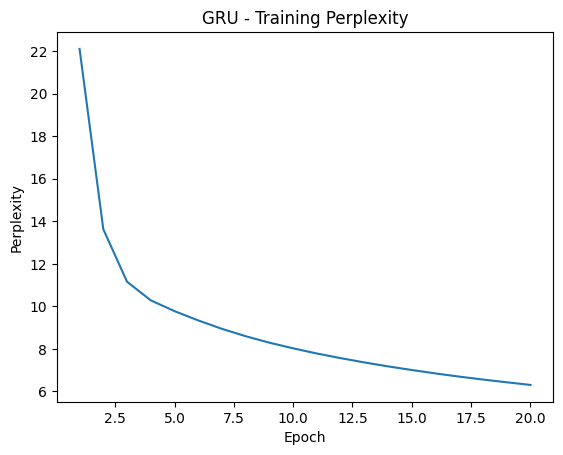

In [30]:
# Cargar modelo y visualizar perplejidad GRU
model_gru = keras.models.load_model('GRU.keras')

epoch_count_gru = range(1, len(history_ppl_gru) + 1)
sns.lineplot(x=epoch_count_gru, y=history_ppl_gru)
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('GRU - Training Perplexity')
plt.show()

#### Comparación de perplexity

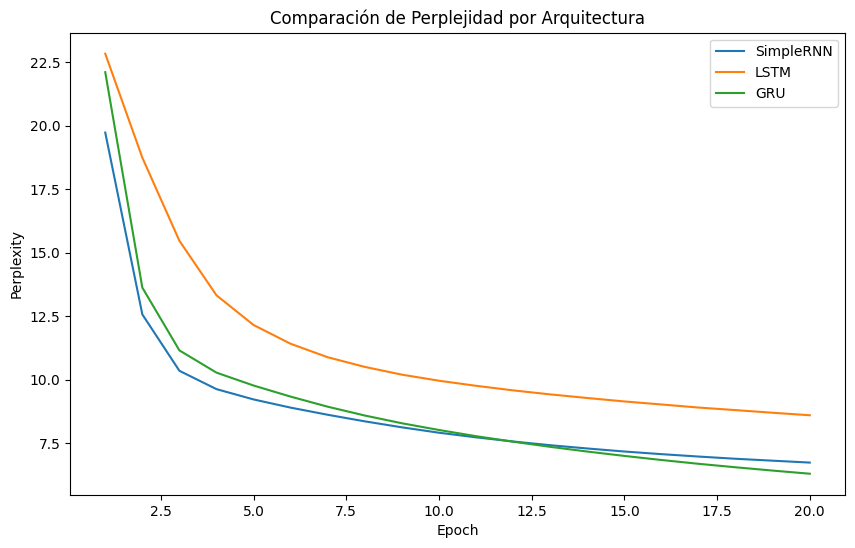

In [31]:
plt.figure(figsize=(10, 6))

sns.lineplot(x=range(1, len(history_ppl) + 1), y=history_ppl, label='SimpleRNN')
sns.lineplot(x=range(1, len(history_ppl_lstm) + 1), y=history_ppl_lstm, label='LSTM')
sns.lineplot(x=range(1, len(history_ppl_gru) + 1), y=history_ppl_gru, label='GRU')

plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('Comparación de Perplejidad por Arquitectura')
plt.legend()
plt.show()

### Generación de texto

In [32]:
# Generación de secuencias con SimpleRNN
show_generations(model)

Input: 'habia una vez'
--------------------------------------------------
Greedy search:
habia una vezar a la contra a las 
algunas

Beam search (determinístico):
habia una vezas de los viajeros d

Beam search (estocástico):
habia una vezar de las 
como de 


In [33]:
# Generación de secuencias con LSTM
show_generations(model_lstm)

Input: 'habia una vez'
--------------------------------------------------
Greedy search:
habia una veza de la conte de la conte de l

Beam search (determinístico):
habia una vezo de la cuento de la

Beam search (estocástico):
habia una vezo de 
comprestaba l


In [34]:
# Generación de secuencias con GRU
show_generations(model_gru)

Input: 'habia una vez'
--------------------------------------------------
Greedy search:
habia una vezas de la compañeros de la comp

Beam search (determinístico):
habia una vezos de la estación de

Beam search (estocástico):
habia una vezar el capor de un du


#### Efecto de la Temperatura

In [35]:
print("Low temp (0.5):")
salidas_gru_sto = beam_search(model, num_beams=5, num_words=30, input="habia una vez", temp=0.5, mode='sto')
print(decode(salidas_gru_sto[0]))

print("Medium temp (1.0):")
salidas_gru_sto = beam_search(model, num_beams=5, num_words=30, input="habia una vez", temp=1.0, mode='sto')
print(decode(salidas_gru_sto[0]))

print("High temp (2.0):")
salidas_gru_sto = beam_search(model, num_beams=5, num_words=30, input="habia una vez", temp=2.0, mode='sto')
print(decode(salidas_gru_sto[0]))

Low temp (0.5):
habia una vezar de las compañeros de la con
Medium temp (1.0):
habia una vezar algunos a las mintes se hab
High temp (2.0):
habia una vezato. —¡an fersala, pararrca ci


In [36]:
print("Low temp (0.5):")
salidas_gru_sto = beam_search(model_lstm, num_beams=5, num_words=30, input="habia una vez", temp=0.5, mode='sto')
print(decode(salidas_gru_sto[0]))

print("Medium temp (1.0):")
salidas_gru_sto = beam_search(model_lstm, num_beams=5, num_words=30, input="habia una vez", temp=1.0, mode='sto')
print(decode(salidas_gru_sto[0]))

print("High temp (2.0):")
salidas_gru_sto = beam_search(model_lstm, num_beams=5, num_words=30, input="habia una vez", temp=2.0, mode='sto')
print(decode(salidas_gru_sto[0]))

Low temp (0.5):
habia una vezo de la conde de la viente en 
Medium temp (1.0):
habia una vezo que la coras que el cuento d
High temp (2.0):
habia una vezun cuy! en l phar 
lenemandec


In [37]:
print("Low temp (0.5):")
salidas_gru_sto = beam_search(model_gru, num_beams=5, num_words=30, input="habia una vez", temp=0.5, mode='sto')
print(decode(salidas_gru_sto[0]))

print("Medium temp (1.0):")
salidas_gru_sto = beam_search(model_gru, num_beams=5, num_words=30, input="habia una vez", temp=1.0, mode='sto')
print(decode(salidas_gru_sto[0]))

print("High temp (2.0):")
salidas_gru_sto = beam_search(model_gru, num_beams=5, num_words=30, input="habia una vez", temp=2.0, mode='sto')
print(decode(salidas_gru_sto[0]))

Low temp (0.5):
habia una vezos de las pasajeros de la core
Medium temp (1.0):
habia una vezo a tiempo de los había para. 
High temp (2.0):
habia una vez de almaba y la imiletesientac


### Demo interactivo con Gradio

In [38]:
import gradio as gr

# Diccionario de modelos disponibles
models_dict = {
    'SimpleRNN': model,
    'LSTM': model_lstm,
    'GRU': model_gru
}

def model_response(human_text, model_name, num_chars):
    selected_model = models_dict[model_name]
    return generate_seq(selected_model, human_text, max_context_size, int(num_chars))

iface = gr.Interface(
    fn=model_response,
    inputs=[
        gr.Textbox(label="Texto inicial", value="habia una vez"),
        gr.Dropdown(choices=['SimpleRNN', 'LSTM', 'GRU'], label="Modelo", value='SimpleRNN'),
        gr.Slider(minimum=10, maximum=100, value=30, step=10, label="Caracteres a generar")
    ],
    outputs=gr.Textbox(label="Texto generado"),
    title="Generador de Texto - Modelo de Lenguaje",
    description="Selecciona un modelo y genera texto a partir de una frase inicial."
)

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://713096d45249d1868b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://713096d45249d1868b.gradio.live


### Conclusiones

En este trabajo se partió de una implementación de un modelo many-to-many donde el input eran caracteres y el output también son caracteres (dado x₀...xₙ se predice x₁...xₙ₊₁). La arquitectura está basada en una SimpleRNN.

Se utilizó One-Hot Encoding (OHE) mediante CategoryEncoding para representar cada carácter como un vector de tamaño vocab_size, permitiendo que el modelo procese secuencias de caracteres de longitud variable.

Se entrenó el modelo y se obtuvo una curva de perplejidad. A menor perplejidad, el modelo tiene mayor certeza sobre cuál será el próximo carácter, lo que indica mejor capacidad predictiva.

Para la comparación con otras arquitecturas se generalizó la creación y entrenamiento del modelo con la finalidad de solo cambiar una capa según la arquitectura deseada. Se mantuvo la arquitectura brindada y se aplicaron capas SimpleRNN (arquitectura inicial), LSTM y GRU. Las capas densas y los dropouts no fueron modificados.

|Modelo|Parámetros Entrenables|
|---|---|
|SimpleRNN|67.468|
|LSTM|228.868|
|GRU|175.668|


Se observa que las arquitecturas se volvieron más complejas con muchos más parámetros a entrenar. En particular, LSTMtiene aproximadamente 3.4 veces más parámetros que SimpleRNN debido a sus 4 compuertas (input, forget, cell state, output). GRU representa un balance intermedio con 2.6 veces más parámetros, gracias a su diseño simplificado con solo 2 compuertas (reset y update).

Esta diferencia de parámetros es clave en este problema donde el entrenamiento se mantuvo equivalente para las tres arquitecturas (20 épocas). El entrenamiento de LSTM fue mucho más lento y obtuvo los peores resultados: la perplejidad siempre fue mayor, indicando que necesitaba más épocas para converger dado su mayor número de parámetros.

Para GRU, luego de la época 12 la perplejidad fue menor que SimpleRNN, demostrando su potencial con entrenamientosuficiente.

|Modelo|Mejor Perplejidad|
|---|---|
|SimpleRNN|6.7446|
|LSTM|8.6064|
|GRU|6.3067|


La evolución de la perplejidad durante el entrenamiento se puede observar en el gráfico comparativo, donde se evidencia la convergencia más rápida de SimpleRNN y el cruce de las curvas de GRU y SimpleRNN alrededor de la época 12.

Otro factor relevante es que la ventana de contexto fue de solo 100 caracteres, donde la memoria a largo plazo de LSTM/GRU no aporta tanto beneficio. Esto explica por qué SimpleRNN funciona tan bien en este caso particular.


#### Generación de secuencias

Todos los modelos trataron la palabra "vez" como un prefijo y no como una palabra completa, generando variantes como "vezar", "vezas", "vezo". Esto es esperable en un modelo de caracteres que aprende patrones a nivel de caracteres sin conocimiento semántico ni de límites de palabras.

Si bien las frases generadas tienen cierta estructura del español, no tienen significado real ni gramática correcta.

Respecto a cada método de búsqueda:
- Greedy: Más repetitivo, tiende a quedar atrapado en patrones como "de la" / "a la"
- Beam determinístico: Produce palabras más reconocibles del español ("viajeros", "cuento", "estación") con salidas más estructuradas
- Beam estocástico: Menos repetitivo pero menos coherente, genera términos inventados como "capor" o "comprestaba"


#### Efecto de la temperatura

Al variar la temperatura en la búsqueda estocástica:
- Baja (0.5): Texto conservador con términos reales ("compañeros", "conde", "pasajeros") pero repetitivo
- Media (1.0): Balance entre coherencia y creatividad, comienzan a aparecer términos inexistentes
- Alta (2.0): Aparecen signos de puntuación inesperados ("—¡", "!") y palabras completamente inventadas fuera de los patrones del español

La temperatura controla la "confianza" del modelo: a menor temperatura elige opciones más probables (conservador), a mayor temperatura todas las opciones se vuelven más equiprobables (creativo pero caótico).


### Conclusión final

Para este problema particular (ventana de 100 caracteres, 20 épocas), SimpleRNN ofrece el mejor balance entre
complejidad y rendimiento. Sin embargo, con más épocas de entrenamiento, GRU podría superarlo gracias a su capacidad de capturar dependencias más largas. LSTM requeriría significativamente más entrenamiento para mostrar sus beneficios, siendo más apropiado para problemas con contextos más extensos.

Posibles mejoras
- Aumentar épocas de entrenamiento para LSTM/GRU
- Probar con ventanas de contexto más largas donde la memoria a largo plazo sea relevante
- Experimentar con embeddings aprendidos en lugar de OHE
- Ajustar hiperparámetros (units, dropout, learning rate)